# SVM - Support Vector Machines

## Part 1 — Implementation
### Exercise 1 — SVM for Classification (Wine Dataset)

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# load data
wine = load_wine()
X, y = wine.data, wine.target

# stratify ensures class balance is maintained in the split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scaling is a critical step when using SVM (same as KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
print(X.shape)
print(y.shape)

(178, 13)
(178,)


In [12]:
print("Tuning hyperparameters on UNSCALED data...")
svm_unscaled = SVC(random_state=42)
grid_search_unscaled = GridSearchCV(svm_unscaled, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search_unscaled.fit(X_train, y_train)

best_svm_unscaled = grid_search_unscaled.best_estimator_
print(f"Best Hyperparameters (Unscaled): {grid_search_unscaled.best_params_}\n")

y_pred_unscaled = best_svm_unscaled.predict(X_test)

Tuning hyperparameters on UNSCALED data...
Best Hyperparameters (Unscaled): {'C': 0.1, 'decision_function_shape': 'ovr', 'kernel': 'linear'}



In [13]:
print("--- Evaluation Metrics (Unscaled) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_unscaled):.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_unscaled, target_names=wine.target_names))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_unscaled))

--- Evaluation Metrics (Unscaled) ---
Accuracy: 0.9722

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


In [3]:
# train and tune SVM
# use GridSearchCV to test combinations of C, kernel, gamma, and multiclass strategy
param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100], 'decision_function_shape': ['ovr', 'ovo']},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.01, 0.1, 1], 'decision_function_shape': ['ovr', 'ovo']}
]

svm = SVC(random_state=42)
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

print("Tuning hyperparameters...")
grid_search.fit(X_train_scaled, y_train)

best_svm = grid_search.best_estimator_
print(f"Best Hyperparameters Found: {grid_search.best_params_}\n")

y_pred = best_svm.predict(X_test_scaled)

Tuning hyperparameters...
Best Hyperparameters Found: {'C': 0.1, 'decision_function_shape': 'ovr', 'kernel': 'linear'}



In [14]:
print("--- Evaluation Metrics (Scaled) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

--- Evaluation Metrics (Scaled) ---
Accuracy: 0.9722

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


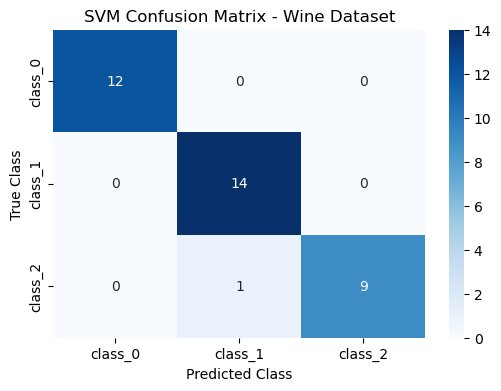

In [6]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.title('SVM Confusion Matrix - Wine Dataset')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

1. Best Test Metric

   - Accuracy is the best primary test metric for this specific case. Because if we look at the "support" column in the classification report, we have 12 instances of class_0, 14 of class_1, and 10 of class_2. Because classes are nicely balanced, accuracy gives a reliable and straightforward picture of how well the model is performing overall (97.22%).
   - Note: If this dataset were highly imbalanced, accuracy would be a misleading trap. In that scenario, we would want to rely on the Macro F1-score to ensure the minority classes aren't being ignored.

2. Best Performing Kernel

   - The linear kernel performed best.
     - We can see this directly at the top of the output:
       - Best Hyperparameters Found: `{'C': 0.1, 'decision_function_shape': 'ovr', 'kernel': 'linear'}`. The grid search determined that a straightforward linear decision boundary, combined with a slightly softer margin `(C = 0.1)`, generalized best during cross-validation.

3. The Effect of Scaling

   - In this specific instance, scaling did not affect performance, as both the scaled and unscaled models achieved the exact same accuracy (97.22%).
   - Without scaling, features with massive numerical ranges (like `Proline`) completely dominated the SVM's distance calculations. It just so happened that in the Wine dataset, these large-scale features are highly predictive, so the model succeeded anyway
   - Scaling is absolutely critical for SVMs, but this case is a rare exception because the Wine dataset is simply a small, clean "toy" dataset used for practice.
   - This is an exception, not the rule. Normally, failing to scale data ruins SVM performance because large but irrelevant features will overpower small but crucial ones.

### Exercise 2 — SVM for Regression (California Housing Dataset)

In [15]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [16]:
california = fetch_california_housing()
X, y = california.data, california.target

X_subset, _, y_subset, _ = train_test_split(
    X, y, train_size=2000, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
svr = SVR()

param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10], 'epsilon': [0.01, 0.1, 0.5]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 1], 'epsilon': [0.01, 0.1, 0.5]}
]

print("Tuning hyperparameters for SVR...")
# We use negative root mean squared error as the scoring metric so higher = better during grid search
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_svr = grid_search.best_estimator_
print(f"Best Hyperparameters Found: {grid_search.best_params_}\n")

y_pred = best_svr.predict(X_test_scaled)

Tuning hyperparameters for SVR...
Best Hyperparameters Found: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}



In [18]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Evaluation Metrics ---")
print(f"RMSE:      {rmse:.4f}")
print(f"MAE:       {mae:.4f}")
print(f"R-squared: {r2:.4f}")

--- Evaluation Metrics ---
RMSE:      0.6843
MAE:       0.4505
R-squared: 0.6430


1. What is your best metric? and why?

   - For this specific housing dataset, **RMSE (Root Mean Squared Error)** is generally the best evaluation metric. This is because RMSE calculates the standard deviation of the prediction errors. And because it squares the errors before averaging them, it penalizes larger errors much more heavily than MAE (Mean Absolute Error). When predicting house prices, being off by a massive amount on a few houses is usually more detrimental than being slightly off on many.
   - The RMSE is $0.6843$. Since the target variable is measured in hundreds of thousands of dollars, this means the model's predictions are off by an average of roughly `$68,430`.
   - While RMSE is best for measuring absolute error, the $R^2$ of $0.6430$ is also highly valuable. It tells us that the model successfully captures about 64.3% of the variance in the California housing prices


2. Which kernel worked best?

   - The **RBF (Radial Basis Function)** kernel worked best.
   - We can see this in your output:
     - Best Hyperparameters Found: `{'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}`.
Unlike the Wine dataset where a linear boundary perfectly separated the classes, housing prices rely on complex, non-linear geographical and demographic relationships. The **RBF kernel** handles this by mapping the features into a higher-dimensional space where a linear hyper-plane can account for those non-linear patterns.

3. How sensitive was performance to $C$ and $\gamma$?

   - The model proved to be highly sensitive to both $C$ and $\gamma$ (gamma), strongly favoring a complex decision boundary.
   - The grid search selected $C = 10$, which was the highest value you offered in the grid `[0.1, 1, 10]`. A high $C$ value tells the SVR to have a very low tolerance for errors outside the $\epsilon$-tube. Instead of settling for a smooth, generalized fit, it warped the decision boundary tightly to capture as many training points as possible. If we had offered higher values (like $100$), it might have pushed even further, though that increases the risk of overfitting.
   - The model selected $\gamma = \text{'scale'}$. Rather than using the hardcoded values `[0.1, 1]`, it chose scikit-learn's default heuristic, which calculates gamma based on the number of features and the variance of the data ($1 / (n\_features \times X.var())$). This highlights that manually setting a static radius for the RBF kernel was less effective than letting the algorithm dynamically scale the variance of the housing features.

## Part 2 — Reflection & Summary

1. What did you learn about SVM?
   - Sensitivity to scaling: SVMs are fundamentally distance-based algorithms. Because they calculate the distance between data points to maximize the margin, failing to scale features usually ruins performance, as variables with large numerical ranges will completely hijack the math.
   - Effect of hyperparameters: Tuning is non-negotiable. The $C$ parameter dictates the bias-variance tradeoff: a low $C$ allows a wider, softer margin with some misclassifications, while a high $C$ strictly enforces correct classification but risks overfitting. In SVR, the $\epsilon$ parameter introduces a unique "tolerance tube" where minor errors are completely ignored by the penalty function.
   - Kernel trick behavior: The kernel trick elegantly bypasses the need for complex feature engineering. By using kernels like RBF, the SVM mathematically projects the data into a higher-dimensional space where non-linear relationships can be separated by a simple, flat hyperplane.
   - Margin intuition: Unlike standard classifiers that just draw a line between groups, SVMs specifically hunt for the widest possible street between classes. The boundary is defined entirely by the hardest-to-classify points right on the edge (the support vectors), making the model highly memory-efficient once trained.
     
2. When might ensemble methods be more beneficial than SVM?
   - Large datasets: SVMs scale poorly, generally hitting $O(n^2)$ to $O(n^3)$ time complexity. When tackling massive datasets—such as using millions of rows of spatial and temporal data for demand forecasting—tree-based frameworks like LightGBM, XGBoost, or Random Forest are vastly superior due to their optimized, highly scalable architectures.
   - Non-linear boundaries: While an SVM relies on expensive kernel transformations to bend around complex data, ensemble methods handle non-linear boundaries natively by partitioning the feature space into hierarchical splits.
   - Interpretability: An RBF SVM is essentially a black box. In contrast, ensemble methods readily provide feature importance scores, allowing you to easily explain which variables are driving the predictions.
   - Computational cost: Grid searching an SVR across thousands of rows is computationally exhausting. Gradient boosting and random forests typically train much faster and often require less aggressive tuning to achieve a strong baseline.
   - Stability: Ensembles are highly robust to outliers and generally do not require strict feature standardization to function properly.
     
3. Any observations or surprises?
   - Did RBF outperform linear?
     - Yes, but context mattered. For the small, linearly separable Wine classification dataset, the linear kernel was perfect. However, for the California Housing regression, the RBF kernel was absolutely necessary to map the complex geographical nuances of real estate prices.
     
   - Did regression perform worse than expected?
     - The metrics for SVR were decent ($R^2$ of ~0.64), but the major limitation was having to downsample the dataset to just 2,000 instances to make training feasible.

   - Was tuning expensive?
     - Yes. Cross-validating the SVR across combinations of $C$, $\gamma$, and $\epsilon$ was noticeably slow, highlighting the severe computational bottleneck of distance-based optimization.

   - Did SVM overfit easily?
     - With a high $C$ or a large $\gamma$ (which shrinks the radius of influence of each point), the model aggressively tightens its boundary around the training data, making it very prone to overfitting if not kept in check by cross-validation.